4. WAP to evaluate the performance of implemented three-layer neural network with variations in activation functions, size of hidden layer, learning rate, batch size and number of epochs.

## Explanation of the Code

This code implements a three-layer neural network (MLP) using TensorFlow (without Keras) to classify the MNIST handwritten digits dataset. It uses feed-forward and backpropagation to train the model.

---
### 1. Importing Libraries
- **TensorFlow:** Used to build the neural network.
- **tensorflow_datasets (tfds):** Fetches the MNIST dataset.
- **numpy:** For array manipulations.
- **matplotlib & seaborn:** Used for visualization.
- **confusion_matrix:** Evaluates classification performance.
---

In [10]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import time
from sklearn.metrics import confusion_matrix


In [11]:

# Enable GPU dynamic memory allocation
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU is available and memory growth is enabled.")
    except RuntimeError as e:
        print(e)
else:
    print("No GPU found. Running on CPU.")

# Disable eager execution for TensorFlow v1 compatibility
tf.compat.v1.disable_eager_execution()

# Load MNIST dataset
mnist, info = tfds.load('mnist', with_info=True, as_supervised=True)

# Fixed Parameters
batch_size = 100
epochs = 50



No GPU found. Running on CPU.


In [12]:
# Variations to test
activations = ['relu']  # Keeping activation fixed to 'relu'
hidden_layer_sizes_double_layer = [(160,100), (100,160), (100,100), (100,60), (60,60)]
learning_rates = [0.1, 0.01, 0.001]

# Function to define activation (ReLU is fixed)
def activation_function(x):
    return tf.nn.relu(x)

# Prepare the dataset
def preprocess(image, label):
    image = tf.reshape(image, [784])
    image = tf.cast(image, tf.float32) / 255.0
    label = tf.one_hot(label, 10)
    return image, label

# Function to build and train the model
def train_and_evaluate(hidden_layers, learning_rate):
    start_time = time.time()  # Start timer

    # Prepare dataset with GPU optimization
    train_data = mnist['train'].map(preprocess).shuffle(60000).batch(batch_size).cache().prefetch(tf.data.experimental.AUTOTUNE)
    test_data = mnist['test'].map(preprocess).batch(batch_size).cache().prefetch(tf.data.experimental.AUTOTUNE)

    # Create iterator
    iterator = tf.compat.v1.data.make_initializable_iterator(train_data)
    next_element = iterator.get_next()

    # Placeholders
    X = tf.compat.v1.placeholder(tf.float32, [None, 784])
    Y = tf.compat.v1.placeholder(tf.float32, [None, 10])

    # Initialize weights and biases
    weights = {}
    biases = {}
    prev_size = 784

    # Define network structure inside GPU scope
    with tf.device('/GPU:0'):
        # Hidden layers
        layer = X
        for i, size in enumerate(hidden_layers):
            weights[f'h{i+1}'] = tf.Variable(tf.random.normal([prev_size, size]))
            biases[f'b{i+1}'] = tf.Variable(tf.random.normal([size]))
            layer = activation_function(tf.add(tf.matmul(layer, weights[f'h{i+1}']), biases[f'b{i+1}']))
            prev_size = size

        # Output layer
        weights['out'] = tf.Variable(tf.random.normal([prev_size, 10]))
        biases['out'] = tf.Variable(tf.random.normal([10]))
        logits = tf.add(tf.matmul(layer, weights['out']), biases['out'])

        # Loss and optimizer
        loss_op = tf.reduce_mean(tf.nn.softmax_cross_entropy_with_logits(logits=logits, labels=Y))
        optimizer = tf.compat.v1.train.AdamOptimizer(learning_rate=learning_rate)
        train_op = optimizer.minimize(loss_op)

        # Accuracy calculation
        correct_pred = tf.equal(tf.argmax(logits, 1), tf.argmax(Y, 1))
        accuracy = tf.reduce_mean(tf.cast(correct_pred, tf.float32))

    # Initialize session
    init = tf.compat.v1.global_variables_initializer()
    loss_history = []
    accuracy_history = []

    with tf.compat.v1.Session() as sess:
        sess.run(init)
        sess.run(iterator.initializer)

        for epoch in range(epochs):
            try:
                while True:
                    batch_x, batch_y = sess.run(next_element)
                    _, loss, acc = sess.run([train_op, loss_op, accuracy], feed_dict={X: batch_x, Y: batch_y})
                    loss_history.append(loss)
                    accuracy_history.append(acc)
            except tf.errors.OutOfRangeError:
                sess.run(iterator.initializer)

        print(f"Completed: Layers={hidden_layers}, LR={learning_rate}")

        # Evaluate on test set
        test_iterator = tf.compat.v1.data.make_initializable_iterator(test_data)
        next_test_element = test_iterator.get_next()
        sess.run(test_iterator.initializer)
        test_acc = 0
        test_count = 0
        y_true, y_pred = [], []

        while True:
            try:
                test_images, test_labels = sess.run(next_test_element)
                acc, preds = sess.run([accuracy, tf.argmax(logits, 1)], feed_dict={X: test_images, Y: test_labels})
                y_true.extend(np.argmax(test_labels, axis=1))
                y_pred.extend(preds)
                test_acc += acc
                test_count += 1
            except tf.errors.OutOfRangeError:
                break

        test_acc /= test_count

        # Compute confusion matrix
        cm = confusion_matrix(y_true, y_pred)

        # Execution time
        execution_time = time.time() - start_time

        return loss_history, accuracy_history, test_acc, cm, execution_time



In [14]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import time
from sklearn.metrics import confusion_matrix


# Taking Learning Rate = 0.1

In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import time
from sklearn.metrics import confusion_matrix

# Disable eager execution
tf.compat.v1.disable_eager_execution()

# Load MNIST dataset
mnist, info = tfds.load('mnist', with_info=True, as_supervised=True)

# Variations to test
activations = ['relu']
# hidden_layer_sizes_single_layer = [256, 128, 64]
learning_rates = [0.1]
batch_sizes = [100]
epochs_list = [50]
hidden_layer_sizes_double_layer = [(160,100), (100,160), (100,100), (100,60), (60,60)]

# Function to define activation
def activation_function(x, activation):
    if activation == 'relu':
        return tf.nn.relu(x)
    elif activation == 'tanh':
        return tf.nn.tanh(x)
    elif activation == 'sigmoid':
        return tf.nn.sigmoid(x)
    else:
        return x  # Default case (no activation)

# Prepare the dataset
def preprocess(image, label):
    image = tf.reshape(image, [784])
    image = tf.cast(image, tf.float32) / 255.0
    label = tf.one_hot(label, 10)
    return image, label

# Function to build and train the model
def train_and_evaluate(activation, hidden_layers, learning_rate, batch_size, epochs):
    start_time = time.time()  # Start timer

    # Prepare data
    train_data = mnist['train'].map(preprocess).shuffle(60000).batch(batch_size)
    test_data = mnist['test'].map(preprocess).batch(batch_size)

    # Create iterator
    iterator = tf.compat.v1.data.make_initializable_iterator(train_data)
    next_element = iterator.get_next()

    # Placeholders
    X = tf.compat.v1.placeholder(tf.float32, [None, 784])
    Y = tf.compat.v1.placeholder(tf.float32, [None, 10])

    # Initialize weights and biases
    weights = {}
    biases = {}
    prev_size = 784

    # Hidden layers
    layer = X
    for i, size in enumerate(hidden_layers):
        weights[f'h{i+1}'] = tf.Variable(tf.random.normal([prev_size, size]))
        biases[f'b{i+1}'] = tf.Variable(tf.random.normal([size]))
        layer = activation_function(tf.add(tf.matmul(layer, weights[f'h{i+1}']), biases[f'b{i+1}']), activation)
        prev_size = size

    # Output layer
    weights['out'] = tf.Variable(tf.random.normal([prev_size, 10]))
    biases['out'] = tf.Variable(tf.random.normal([10]))
    logits = tf.add(tf.matmul(layer, weights['out']), biases['out'])

    # Loss and optimizer
    loss_op = tf.reduce_mean(tf.nn.softmax_cross_entropy_with_logits(logits=logits, labels=Y))
    optimizer = tf.compat.v1.train.AdamOptimizer(learning_rate=learning_rate)
    train_op = optimizer.minimize(loss_op)

    # Accuracy calculation
    correct_pred = tf.equal(tf.argmax(logits, 1), tf.argmax(Y, 1))
    accuracy = tf.reduce_mean(tf.cast(correct_pred, tf.float32))

    # Initialize session
    init = tf.compat.v1.global_variables_initializer()
    loss_history = []
    accuracy_history = []

    with tf.compat.v1.Session() as sess:
        sess.run(init)
        sess.run(iterator.initializer)

        for epoch in range(epochs):
            try:
                while True:
                    batch_x, batch_y = sess.run(next_element)
                    _, loss, acc = sess.run([train_op, loss_op, accuracy], feed_dict={X: batch_x, Y: batch_y})
                    loss_history.append(loss)
                    accuracy_history.append(acc)
            except tf.errors.OutOfRangeError:
                sess.run(iterator.initializer)

        print(f"Completed: Activation={activation}, Layers={hidden_layers}, LR={learning_rate}, Batch={batch_size}, Epochs={epochs}")

        # Evaluate on test set
        test_iterator = tf.compat.v1.data.make_initializable_iterator(test_data)
        next_test_element = test_iterator.get_next()
        sess.run(test_iterator.initializer)
        test_acc = 0
        test_count = 0
        y_true, y_pred = [], []

        while True:
            try:
                test_images, test_labels = sess.run(next_test_element)
                acc, preds = sess.run([accuracy, tf.argmax(logits, 1)], feed_dict={X: test_images, Y: test_labels})
                y_true.extend(np.argmax(test_labels, axis=1))
                y_pred.extend(preds)
                test_acc += acc
                test_count += 1
            except tf.errors.OutOfRangeError:
                break

        test_acc /= test_count

        # Compute confusion matrix
        cm = confusion_matrix(y_true, y_pred)

        # Execution time
        execution_time = time.time() - start_time

        return loss_history, accuracy_history, test_acc, cm, execution_time

# Store results
results_single_layer = []
results_double_layer = []

# Run experiments for single-layer networks
# for activation in activations:
#     for hidden_size in hidden_layer_sizes_single_layer:
#         for lr in learning_rates:
#             for batch in batch_sizes:
#                 for epochs in epochs_list:
#                     loss_hist, acc_hist, test_acc, cm, exec_time = train_and_evaluate(
#                         activation, [hidden_size], lr, batch, epochs
#                     )
#                     results_single_layer.append([activation, 1, lr, batch, epochs, loss_hist[-1], acc_hist[-1], test_acc, cm, exec_time])

# # Run experiments for double-layer networks
for activation in activations:
    for hidden_sizes in hidden_layer_sizes_double_layer:
        for lr in learning_rates:
            for batch in batch_sizes:
                for epochs in epochs_list:
                    loss_hist, acc_hist, test_acc, cm, exec_time = train_and_evaluate(
                        activation, list(hidden_sizes), lr, batch, epochs
                    )
                    results_double_layer.append([activation, 2, lr, batch, epochs, loss_hist[-1], acc_hist[-1], test_acc, cm, exec_time])

# Convert to DataFrame for display
columns = ["Activation", "No. of Layers", "Learning Rate", "Batch Size", "Epochs", "Final Loss", "Final Accuracy", "Test Accuracy", "Confusion Matrix", "Execution Time"]

# df_single_layer = pd.DataFrame(results_single_layer, columns=columns)
df_double_layer = pd.DataFrame(results_double_layer, columns=columns)

# Display results
# print("\nSingle Layer Results:")
# display(df_single_layer)

print("\nDouble Layer Results:")
display(df_double_layer)


Completed: Activation=relu, Layers=[160, 100], LR=0.1, Batch=100, Epochs=50
Completed: Activation=relu, Layers=[100, 160], LR=0.1, Batch=100, Epochs=50
Completed: Activation=relu, Layers=[100, 100], LR=0.1, Batch=100, Epochs=50
Completed: Activation=relu, Layers=[100, 60], LR=0.1, Batch=100, Epochs=50
Completed: Activation=relu, Layers=[60, 60], LR=0.1, Batch=100, Epochs=50

Double Layer Results:


,Activation,No. of Layers,Learning Rate,Batch Size,Epochs,Final Loss,Final Accuracy,Test Accuracy,Confusion Matrix,Execution Time
0,relu,2,0.1,100,50,2.308583,0.12,0.0958,"[[0, 0, 0, 0, 0, 0, 980, 0, 0, 0], [0, 0, 0, 0...",183.761208
1,relu,2,0.1,100,50,1.885162,0.18,0.2072,"[[0, 70, 0, 0, 0, 0, 0, 0, 0, 910], [0, 1130, ...",159.872432
2,relu,2,0.1,100,50,1.624843,0.29,0.2928,"[[0, 0, 972, 0, 0, 0, 0, 8, 0, 0], [0, 952, 73...",156.161735
3,relu,2,0.1,100,50,2.322600,0.05,0.1036,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 980], [0, 27, 0, ...",159.150171
4,relu,2,0.1,100,50,1.614350,0.30,0.2794,"[[0, 0, 0, 0, 0, 0, 979, 1, 0, 0], [0, 927, 0,...",152.482294


## Function to plot confusion matrix

Confusion matrix 0 shape: (10, 10)
Confusion matrix 1 shape: (10, 10)
Confusion matrix 2 shape: (10, 10)
Confusion matrix 3 shape: (10, 10)
Confusion matrix 4 shape: (10, 10)


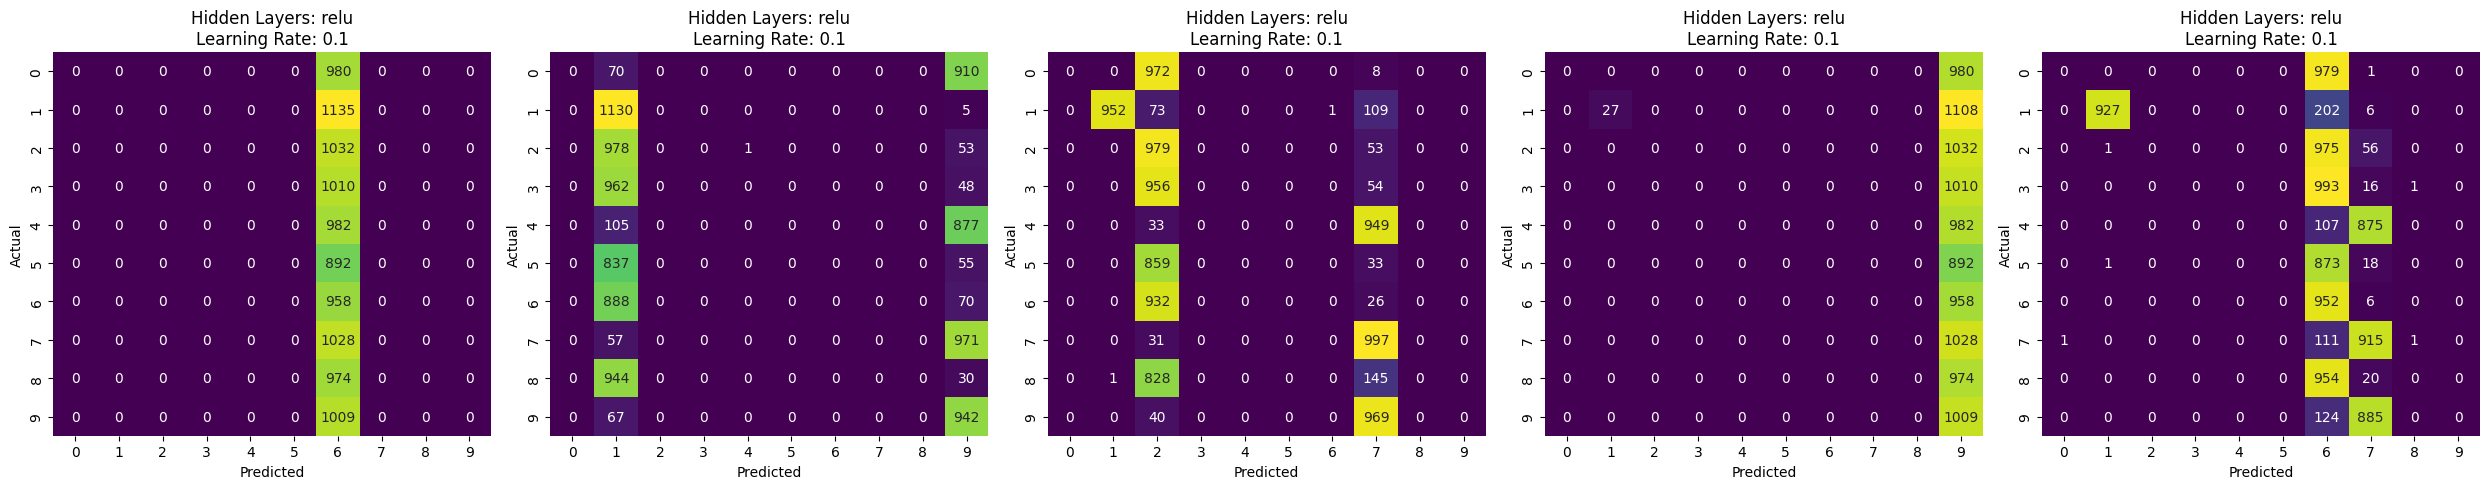

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_confusion_matrices(conf_matrices, hidden_layer_configs, learning_rates):
    num_matrices = len(conf_matrices)
    fig, axes = plt.subplots(1, num_matrices, figsize=(5 * num_matrices, 5))
    
    if num_matrices == 1:
        axes = [axes]
    
    for i, (conf_matrix, hidden_layers, lr) in enumerate(zip(conf_matrices, hidden_layer_configs, learning_rates)):
        print(f"Confusion matrix {i} shape: {conf_matrix.shape}")  # Debugging line
        if conf_matrix.ndim != 2:
            raise ValueError(f"Confusion matrix {i} is not 2-dimensional. Shape: {conf_matrix.shape}")
        sns.heatmap(conf_matrix, annot=True, fmt='d', ax=axes[i], cmap='viridis', cbar=False)
        axes[i].set_title(f'Hidden Layers: {hidden_layers}\nLearning Rate: {lr}')
        axes[i].set_xlabel('Predicted')
        axes[i].set_ylabel('Actual')
    
    plt.tight_layout()
    plt.show()

# Extract data
conf_matrices = [result[8] for result in results_double_layer]  # Extract confusion matrices
hidden_layer_configs = [result[0] for result in results_double_layer]  # Extract hidden layer configurations
learning_rates = [result[2] for result in results_double_layer]  # Extract learning rates

# Call the function to plot
plot_confusion_matrices(conf_matrices, hidden_layer_configs, learning_rates)

## Function to plot loss curve

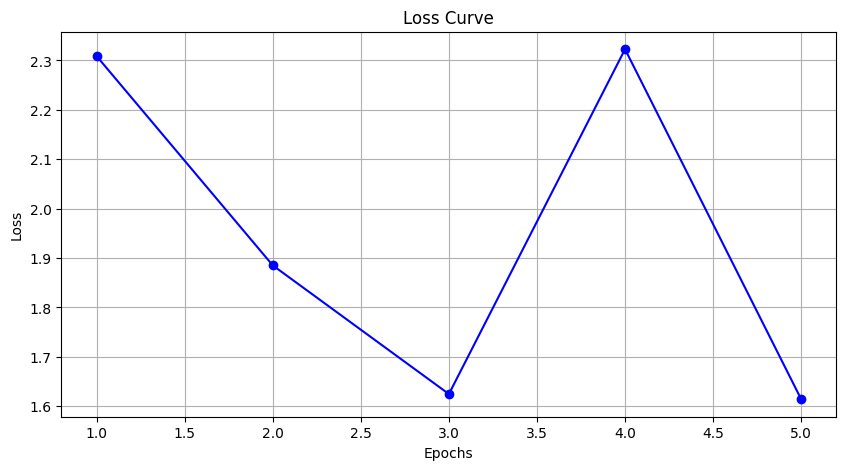

In [26]:
def plot_loss_curve(loss_values, epochs):
    plt.figure(figsize=(10, 5))
    plt.plot(epochs, loss_values, marker='o', linestyle='-', color='b')
    plt.title('Loss Curve')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.show()

# Extract data
loss_values = [result[5] for result in results_double_layer]  # Extract loss values
epochs = list(range(1, len(loss_values) + 1))  # Assuming each result corresponds to an epoch

# Call the function to plot loss curve
plot_loss_curve(loss_values, epochs)

## Now taking Learning rate = 1

In [30]:
# Now taking Learning rate = 1 and Batch size = 100
learning_rates = [1]
batch_sizes = [100]
epochs_list = [50]
hidden_layer_sizes_double_layer = [(160,100), (100,160), (100,100), (100,60), (60,60)]

# Store results
results_double_layer_Lr_1 = []

# # Run experiments for double-layer networks
for activation in activations:
    for hidden_sizes in hidden_layer_sizes_double_layer:
        for lr in learning_rates:
            for batch in batch_sizes:
                for epochs in epochs_list:
                    loss_hist, acc_hist, test_acc, cm, exec_time = train_and_evaluate(
                        activation, list(hidden_sizes), lr, batch, epochs
                    )
                    results_double_layer_Lr_1.append([activation, 2, lr, batch, epochs, loss_hist[-1], acc_hist[-1], test_acc, cm, exec_time])

# Convert to DataFrame for display
columns = ["Activation", "No. of Layers", "Learning Rate", "Batch Size", "Epochs", "Final Loss", "Final Accuracy", "Test Accuracy", "Confusion Matrix", "Execution Time"]

df_double_layer_Lr_1 = pd.DataFrame(results_double_layer_Lr_1, columns=columns)

print("\nDouble Layer Results:")
display(df_double_layer_Lr_1)

Completed: Activation=relu, Layers=[160, 100], LR=1, Batch=100, Epochs=50
Completed: Activation=relu, Layers=[100, 160], LR=1, Batch=100, Epochs=50
Completed: Activation=relu, Layers=[100, 100], LR=1, Batch=100, Epochs=50
Completed: Activation=relu, Layers=[100, 60], LR=1, Batch=100, Epochs=50
Completed: Activation=relu, Layers=[60, 60], LR=1, Batch=100, Epochs=50

Double Layer Results:


,Activation,No. of Layers,Learning Rate,Batch Size,Epochs,Final Loss,Final Accuracy,Test Accuracy,Confusion Matrix,Execution Time
0,relu,2,1,100,50,2.346345,0.07,0.1028,"[[0, 0, 0, 0, 0, 0, 0, 980, 0, 0], [0, 0, 0, 0...",171.549335
1,relu,2,1,100,50,2.336296,0.14,0.1135,"[[0, 980, 0, 0, 0, 0, 0, 0, 0, 0], [0, 1135, 0...",154.917728
2,relu,2,1,100,50,2.401200,0.03,0.1027,"[[0, 0, 0, 0, 0, 0, 0, 980, 0, 0], [0, 0, 0, 0...",159.681840
3,relu,2,1,100,50,2.366193,0.12,0.1010,"[[0, 0, 0, 980, 0, 0, 0, 0, 0, 0], [0, 0, 0, 1...",132.147303
4,relu,2,1,100,50,2.329185,0.11,0.0980,"[[980, 0, 0, 0, 0, 0, 0, 0, 0, 0], [1135, 0, 0...",115.431310


## Ploting confusion matrix and loss curve

Confusion matrix 0 shape: (10, 10)
Confusion matrix 1 shape: (10, 10)
Confusion matrix 2 shape: (10, 10)
Confusion matrix 3 shape: (10, 10)
Confusion matrix 4 shape: (10, 10)


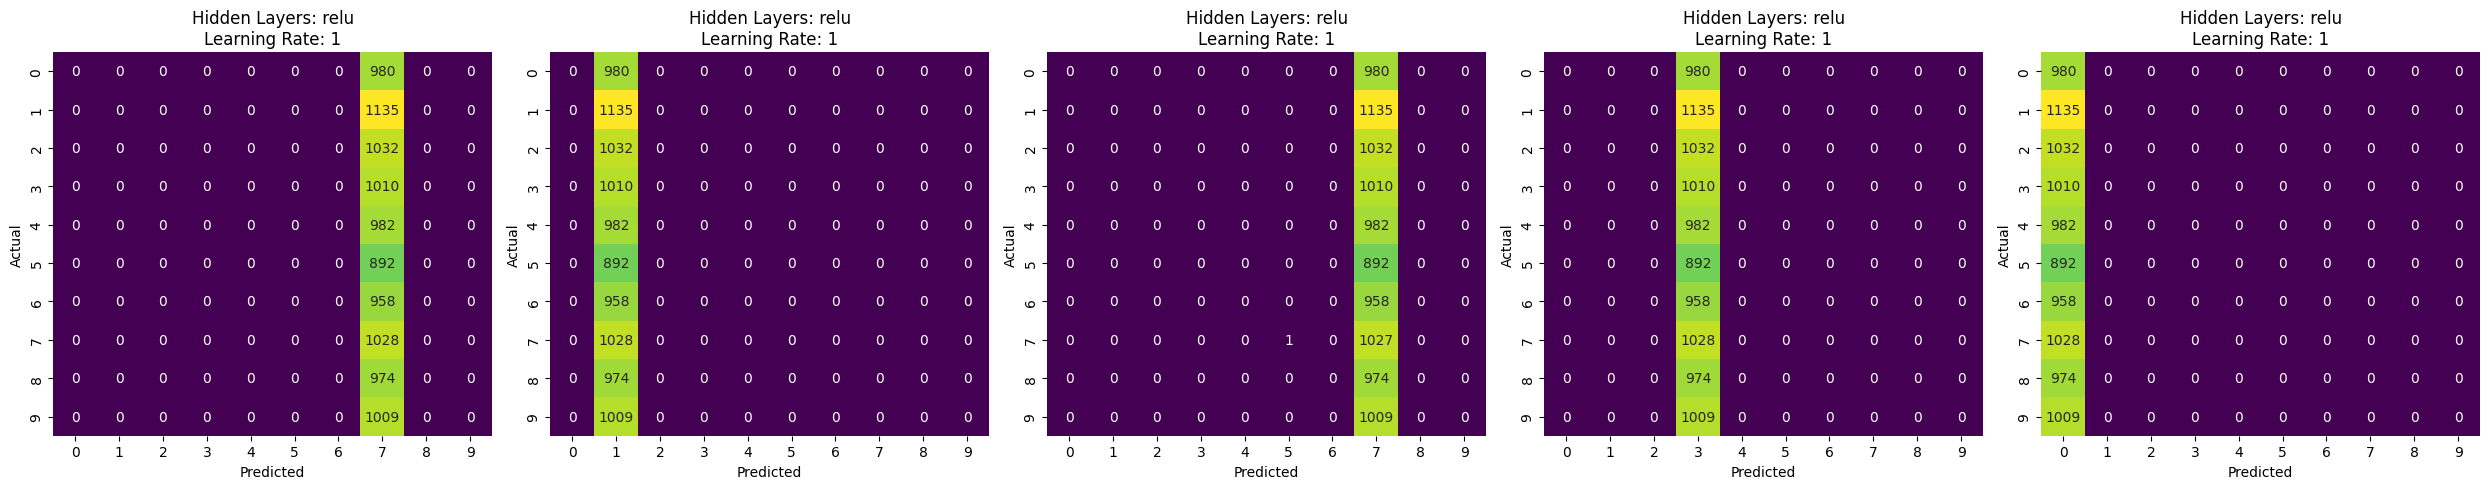

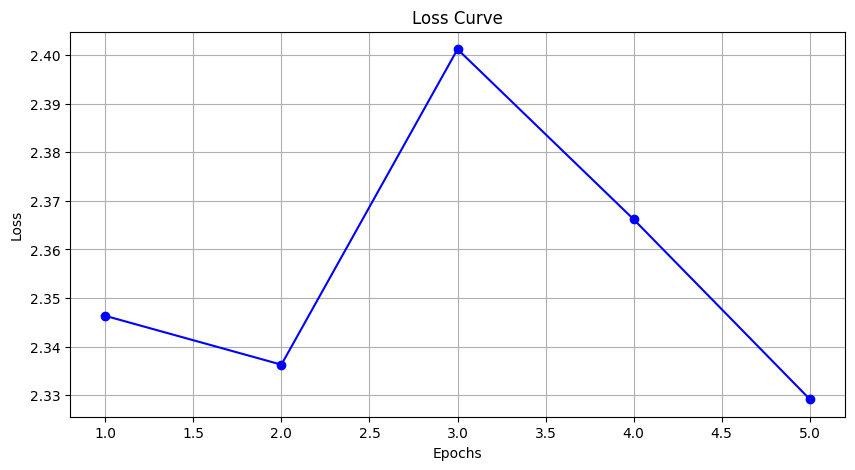

In [31]:
# Extract data
conf_matrices = [result[8] for result in results_double_layer_Lr_1]  # Extract confusion matrices
hidden_layer_configs = [result[0] for result in results_double_layer_Lr_1]  # Extract hidden layer configurations
learning_rates = [result[2] for result in results_double_layer_Lr_1]  # Extract learning rates

loss_values = [result[5] for result in results_double_layer_Lr_1]  # Extract loss values
epochs = list(range(1, len(loss_values) + 1))  # Assuming each result corresponds to an epoch

# Call the function to plot
plot_confusion_matrices(conf_matrices, hidden_layer_configs, learning_rates)

# Call the function to plot loss curve
plot_loss_curve(loss_values, epochs)

## Now taking Learning rate = 0.01

In [32]:
# Now taking Learning rate = 1 and Batch size = 100
learning_rates = [0.01]
batch_sizes = [100]
epochs_list = [50]
hidden_layer_sizes_double_layer = [(160,100), (100,160), (100,100), (100,60), (60,60)]

# Store results
results_double_layer_Lr_01 = []

# # Run experiments for double-layer networks
for activation in activations:
    for hidden_sizes in hidden_layer_sizes_double_layer:
        for lr in learning_rates:
            for batch in batch_sizes:
                for epochs in epochs_list:
                    loss_hist, acc_hist, test_acc, cm, exec_time = train_and_evaluate(
                        activation, list(hidden_sizes), lr, batch, epochs
                    )
                    results_double_layer_Lr_01.append([activation, 2, lr, batch, epochs, loss_hist[-1], acc_hist[-1], test_acc, cm, exec_time])

# Convert to DataFrame for display
columns = ["Activation", "No. of Layers", "Learning Rate", "Batch Size", "Epochs", "Final Loss", "Final Accuracy", "Test Accuracy", "Confusion Matrix", "Execution Time"]

df_double_layer_Lr_01 = pd.DataFrame(results_double_layer_Lr_01, columns=columns)

print("\nDouble Layer Results:")
display(df_double_layer_Lr_01)

Completed: Activation=relu, Layers=[160, 100], LR=0.01, Batch=100, Epochs=50
Completed: Activation=relu, Layers=[100, 160], LR=0.01, Batch=100, Epochs=50
Completed: Activation=relu, Layers=[100, 100], LR=0.01, Batch=100, Epochs=50
Completed: Activation=relu, Layers=[100, 60], LR=0.01, Batch=100, Epochs=50
Completed: Activation=relu, Layers=[60, 60], LR=0.01, Batch=100, Epochs=50

Double Layer Results:


,Activation,No. of Layers,Learning Rate,Batch Size,Epochs,Final Loss,Final Accuracy,Test Accuracy,Confusion Matrix,Execution Time
0,relu,2,0.01,100,50,0.001497,1.00,0.9715,"[[964, 0, 1, 0, 0, 0, 5, 1, 7, 2], [0, 1110, 1...",134.371367
1,relu,2,0.01,100,50,0.059608,0.97,0.9658,"[[962, 1, 1, 2, 1, 2, 4, 1, 6, 0], [0, 1113, 4...",126.801327
2,relu,2,0.01,100,50,0.267049,0.97,0.9659,"[[958, 0, 2, 1, 1, 2, 2, 1, 3, 10], [0, 1122, ...",141.872940
3,relu,2,0.01,100,50,0.003945,1.00,0.9672,"[[959, 1, 5, 2, 0, 2, 9, 1, 1, 0], [0, 1125, 5...",158.868021
4,relu,2,0.01,100,50,0.020288,0.99,0.9628,"[[970, 0, 1, 0, 0, 0, 4, 1, 4, 0], [0, 1117, 4...",141.993401


## Ploting confusion matrix and loss curve

Confusion matrix 0 shape: (10, 10)
Confusion matrix 1 shape: (10, 10)
Confusion matrix 2 shape: (10, 10)
Confusion matrix 3 shape: (10, 10)
Confusion matrix 4 shape: (10, 10)


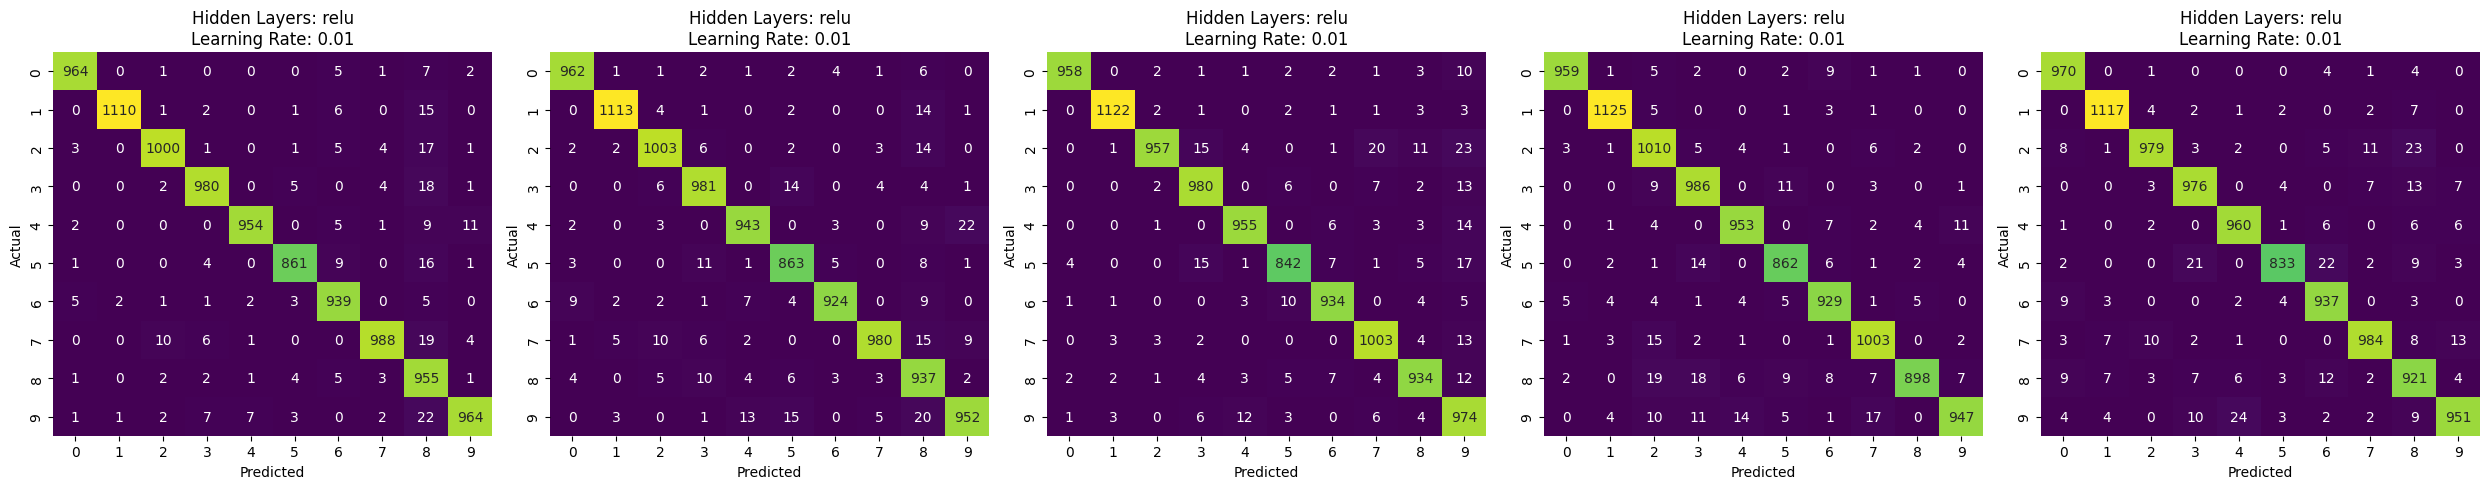

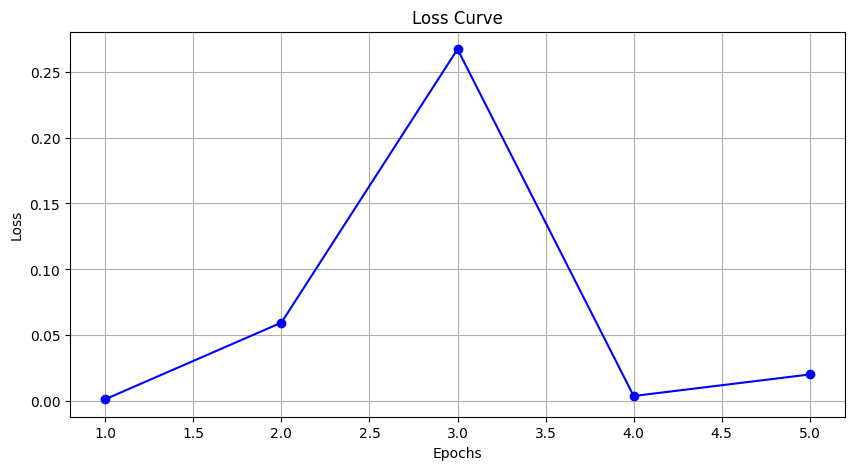

In [33]:
# Extract data
conf_matrices = [result[8] for result in results_double_layer_Lr_01]  # Extract confusion matrices
hidden_layer_configs = [result[0] for result in results_double_layer_Lr_01]  # Extract hidden layer configurations
learning_rates = [result[2] for result in results_double_layer_Lr_01]  # Extract learning rates

loss_values = [result[5] for result in results_double_layer_Lr_01]  # Extract loss values
epochs = list(range(1, len(loss_values) + 1))  # Assuming each result corresponds to an epoch

# Call the function to plot
plot_confusion_matrices(conf_matrices, hidden_layer_configs, learning_rates)

# Call the function to plot loss curve
plot_loss_curve(loss_values, epochs)